# BIOMASS L1B Beta0 → Gamma0 on intersecting 100 km MGRS tiles

This proof of concept turns one BIOMASS L1B acquisition into four linear-Gamma0
images for every standard 100 km MGRS tile whose WGS84 bounding box intersects
the source Item bbox. The `mgrs` package derives each tile's native UTM extent
from its MGRS identifier. Each output has an exact 1,000 × 1,000, 100 m north-up
grid. There is no EPSG:4326 output warp.

The Item bbox is only a cheap candidate filter. Each candidate tile perimeter
is densified and back-projected through the source GCPs before pixels are read,
which rejects bbox false positives and supports tiles in different UTM zones.

## Required input

Install the `mgrs` package with the notebook dependencies. It derives standard
100 km tile IDs, UTM CRS codes, and exact UTM extents directly, so no MGRS tile
extent geopackage or field configuration is required.

In [7]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import requests
from affine import Affine
from mgrs import MGRS
from mgrs.core import MGRSError
from pyproj import Transformer
from pystac_client import Client
from rasterio.control import GroundControlPoint
from rasterio.enums import Resampling
from rasterio.transform import GCPTransformer
from rasterio.warp import reproject
from rasterio.windows import Window
from shapely.geometry import box

from esa_biomass_gamma0.calibration import (
    calculate_gamma0,
    parse_annotation,
    read_lut_coordinates,
    sample_gamma_nought,
    window_coordinates,
)
import main

plt.rcParams.update(
    {"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False}
)

ITEM_ID = (
    "BIO_S2_DGM__1S_20260601T121355_20260601T121415_T_G01_M03_C07_T008_F100_02_DSD6MY"
)
OUTPUT_ROOT = Path("outputs")
WRITE_COGS = False

RESOLUTION_M = 100.0
MGRS_TILE_SIZE_M = 100_000.0
WINDOW_PADDING_PIXELS = 64
BOUNDARY_SPACING_M = 1_000.0
NODATA = -9999.0
POLARIZATIONS = ("HH", "HV", "VH", "VV")
STAC_URL = main.ESA_STAC_API_URL
MGRS_CONVERTER = MGRS()


def get_access_token() -> str:
    """Exchange configured MAAP credentials for a short-lived access token."""
    client_secret = os.getenv("ESA_MAAP_CLIENT_SECRET")
    offline_token = os.getenv("ESA_OFFLINE_TOKEN")
    if not all((client_secret, offline_token)):
        raise ValueError(
            "Set ESA_MAAP_CLIENT_SECRET and ESA_OFFLINE_TOKEN before running."
        )

    response = requests.post(
        "https://iam.maap.eo.esa.int/realms/esa-maap/protocol/openid-connect/token",
        data={
            "client_id": os.getenv("MAAP_CLIENT_ID", "offline-token"),
            "client_secret": client_secret,
            "grant_type": "refresh_token",
            "refresh_token": offline_token,
            "scope": "offline_access openid",
        },
        timeout=30,
    )
    response.raise_for_status()
    token = response.json().get("access_token")
    if not token:
        raise RuntimeError("MAAP did not return an access token.")
    return token


def percentile_rgb(data: np.ndarray, bands: tuple[int, int, int]) -> np.ndarray:
    """Return a robust 2nd–98th percentile RGB display stretch."""
    rgb = data[list(bands)].transpose(1, 2, 0).astype("float32", copy=True)
    for channel in range(3):
        low, high = np.nanpercentile(rgb[..., channel], (2, 98))
        rgb[..., channel] = np.clip((rgb[..., channel] - low) / (high - low), 0, 1)
    return rgb


def mgrs_tile_extent(tile_id: str) -> tuple[int, str, float, float, float, float]:
    """Return a 100 km MGRS tile's UTM zone, hemisphere, and exact bounds."""
    zone, hemisphere, xmin, ymin = MGRS_CONVERTER.MGRSToUTM(tile_id)
    return (
        zone,
        hemisphere,
        xmin,
        ymin,
        xmin + MGRS_TILE_SIZE_M,
        ymin + MGRS_TILE_SIZE_M,
    )

## 1. Retrieve the source metadata and ancillary files

The Beta0 TIFF is not downloaded to the cache. GDAL opens its remote header and
reads an accepted pixel window through `/vsicurl` range requests for each tile.
The smaller LUT and annotation are cached locally because calibration needs
them in full or as a NetCDF slice.

In [8]:
client = Client.open(STAC_URL)
item = next(
    client.search(collections=["BiomassLevel1b"], ids=[ITEM_ID], limit=1).items(), None
)
if item is None:
    raise ValueError(f"No BIOMASS L1B product found for {ITEM_ID!r}")

try:
    beta_url = item.assets["enclosure_tiff"].href
    ancillary_urls = {
        "lut": item.assets["enclosure_nc"].href,
        "annotation": item.assets["enclosure_annot_xml"].href,
    }
except KeyError as error:
    raise ValueError(f"{item.id} is missing required asset {error.args[0]}") from error

asset_paths = main.cache_paths(item.id, Path("/tmp"))
access_token = get_access_token()
missing_assets = {
    name: url for name, url in ancillary_urls.items() if not asset_paths[name].exists()
}
if missing_assets:
    downloaded_assets = await main.fetch_assets(missing_assets, access_token)
    for name, contents in downloaded_assets.items():
        main.write_cached_asset(asset_paths[name], contents)

print(f"Product: {item.id}")
print(f"Acquired: {item.datetime:%Y-%m-%d %H:%M:%S UTC}")
print("Beta0: remote /vsicurl window read")
for name in ancillary_urls:
    print(
        f"{name:>10}: {asset_paths[name]} ({asset_paths[name].stat().st_size / 1_000_000:.1f} MB)"
    )

Product: BIO_S2_DGM__1S_20260601T121355_20260601T121415_T_G01_M03_C07_T008_F100_02_DSD6MY
Acquired: 2026-06-01 12:13:55 UTC
Beta0: remote /vsicurl window read
       lut: /tmp/biomass__BIO_S2_DGM__1S_20260601T121355_20260601T121415_T_G01_M03_C07_T008_F100_02_DSD6MY__lut.nc (50.0 MB)
annotation: /tmp/biomass__BIO_S2_DGM__1S_20260601T121355_20260601T121415_T_G01_M03_C07_T008_F100_02_DSD6MY__annotation.xml (0.9 MB)


## 2. Use the Item bbox to find candidate MGRS tiles

The STAC Item bbox is WGS84. The `mgrs` package enumerates 100 km MGRS squares
in every intersecting UTM zone and derives their exact UTM extents. A tile's
WGS84 envelope filters the candidates. This is deliberately permissive: a bbox
can select tiles that the curved GCP footprint does not cover. The later GCP
back-projection is the authoritative tile-overlap test.

In [9]:
if item.bbox is None:
    raise ValueError(f"{item.id} has no STAC bbox for candidate-tile selection.")
if len(item.bbox) == 4:
    west, south, east, north = item.bbox
elif len(item.bbox) == 6:
    west, south, _, east, north, _ = item.bbox
else:
    raise ValueError(f"Unsupported STAC bbox length: {len(item.bbox)}")
if west > east:
    raise ValueError("Antimeridian-crossing STAC bboxes are not supported.")
if south < -80 or north > 84:
    raise ValueError("This UTM-only workflow does not support polar MGRS tiles.")


def mgrs_tile_ids_for_bbox(
    west: float, south: float, east: float, north: float
) -> list[str]:
    """Return 100 km MGRS tile IDs whose WGS84 envelopes intersect a bbox."""
    source_bbox = box(west, south, east, north)
    west_zone = max(1, int(np.floor((west + 180) / 6)) + 1)
    east_zone = min(60, int(np.floor((east + 180) / 6)) + 1)
    zones = range(max(1, west_zone - 1), min(60, east_zone + 1) + 1)
    hemispheres = (
        ("S", "N") if south < 0 < north else (("S",) if north <= 0 else ("N",))
    )
    tile_ids = set()

    for zone in zones:
        for hemisphere in hemispheres:
            epsg = (32600 if hemisphere == "N" else 32700) + zone
            transformer = Transformer.from_crs(
                "EPSG:4326", f"EPSG:{epsg}", always_xy=True
            )
            xmin, ymin, xmax, ymax = transformer.transform_bounds(
                west, south, east, north, densify_pts=21
            )
            eastings = range(
                max(100_000, int(np.floor(xmin / MGRS_TILE_SIZE_M) - 1) * 100_000),
                min(900_000, int(np.floor(xmax / MGRS_TILE_SIZE_M) + 1) * 100_000) + 1,
                100_000,
            )
            northings = range(
                max(0, int(np.floor(ymin / MGRS_TILE_SIZE_M) - 1) * 100_000),
                min(9_900_000, int(np.floor(ymax / MGRS_TILE_SIZE_M) + 1) * 100_000)
                + 1,
                100_000,
            )
            to_wgs84 = Transformer.from_crs(f"EPSG:{epsg}", "EPSG:4326", always_xy=True)
            for easting in eastings:
                for northing in northings:
                    try:
                        provisional_id = MGRS_CONVERTER.UTMToMGRS(
                            zone, hemisphere, easting, northing, MGRSPrecision=0
                        )
                        _, _, tile_xmin, tile_ymin, tile_xmax, tile_ymax = (
                            mgrs_tile_extent(provisional_id)
                        )
                        center_longitude, center_latitude = to_wgs84.transform(
                            (tile_xmin + tile_xmax) / 2, (tile_ymin + tile_ymax) / 2
                        )
                        # UTM cells can straddle an MGRS latitude-band boundary.
                        tile_id = MGRS_CONVERTER.toMGRS(
                            center_latitude, center_longitude, MGRSPrecision=0
                        )
                        (
                            tile_zone,
                            tile_hemisphere,
                            tile_xmin,
                            tile_ymin,
                            tile_xmax,
                            tile_ymax,
                        ) = mgrs_tile_extent(tile_id)
                    except MGRSError:
                        continue
                    if (tile_zone, tile_hemisphere) != (zone, hemisphere):
                        continue
                    tile_bounds = to_wgs84.transform_bounds(
                        tile_xmin, tile_ymin, tile_xmax, tile_ymax, densify_pts=21
                    )
                    if box(*tile_bounds).intersects(source_bbox):
                        tile_ids.add(tile_id)

    return sorted(tile_ids)


candidate_tile_ids = mgrs_tile_ids_for_bbox(west, south, east, north)
if not candidate_tile_ids:
    raise ValueError(f"{item.id} bbox does not intersect any MGRS tiles.")

print(f"Source bbox candidate tiles: {len(candidate_tile_ids)}")
for tile_id in candidate_tile_ids:
    zone, hemisphere, *_ = mgrs_tile_extent(tile_id)
    print(f"{tile_id} (EPSG:{(32600 if hemisphere == 'N' else 32700) + zone})")

Source bbox candidate tiles: 6
48VXP (EPSG:32648)
48VXQ (EPSG:32648)
49VCJ (EPSG:32649)
49VCK (EPSG:32649)
49VDJ (EPSG:32649)
49VDK (EPSG:32649)


## 3. Back-project each candidate MGRS boundary to a source-pixel window

Each tile boundary is densified in its native UTM CRS before conversion to the
source GCP CRS. GDAL's GCP transformer maps those map coordinates back into
radar pixels. A padded, clipped window is accepted only when it overlaps the
source raster, making this check more precise than the source bbox.

In [10]:
def target_grid(tile_id: str) -> dict:
    """Build one exact 100 km UTM grid from an MGRS tile identifier."""
    zone, hemisphere, xmin, ymin, xmax, ymax = mgrs_tile_extent(tile_id)
    tile_epsg = (32600 if hemisphere == "N" else 32700) + zone
    tile_crs = rasterio.crs.CRS.from_epsg(tile_epsg)
    transform = Affine.translation(xmin, ymax) * Affine.scale(
        RESOLUTION_M, -RESOLUTION_M
    )
    shape = (round(MGRS_TILE_SIZE_M / RESOLUTION_M),) * 2
    assert shape == (1_000, 1_000)
    return {
        "tile_id": tile_id,
        "epsg": tile_epsg,
        "crs": tile_crs,
        "geometry": box(xmin, ymin, xmax, ymax),
        "transform": transform,
        "shape": shape,
    }


def densified_boundary(geometry, spacing_m: float) -> tuple[np.ndarray, np.ndarray]:
    """Return a polygon perimeter sampled no farther apart than ``spacing_m``."""
    ring = np.asarray(geometry.exterior.coords, dtype="float64")
    points = []
    for start, end in zip(ring[:-1], ring[1:], strict=True):
        count = max(1, int(np.ceil(np.hypot(*(end - start)) / spacing_m)))
        points.append(start + (end - start) * np.arange(count)[:, None] / count)
    boundary = np.concatenate(points)
    return boundary[:, 0], boundary[:, 1]


def gcp_pixel_window(
    tile_grid: dict,
    gcps: list[GroundControlPoint],
    gcp_crs: rasterio.crs.CRS,
    source_height: int,
    source_width: int,
) -> Window | None:
    """Back-project one MGRS boundary and return its padded source-pixel window."""
    if not gcps or gcp_crs is None:
        raise ValueError("Beta0 is missing GCPs or a GCP CRS.")

    tile_x, tile_y = densified_boundary(tile_grid["geometry"], BOUNDARY_SPACING_M)
    to_gcp = Transformer.from_crs(tile_grid["crs"], gcp_crs, always_xy=True)
    gcp_x, gcp_y = to_gcp.transform(tile_x, tile_y)
    with GCPTransformer(gcps) as transformer:
        rows, cols = transformer.rowcol(gcp_x, gcp_y)

    rows = np.asarray(rows, dtype="float64")
    cols = np.asarray(cols, dtype="float64")
    valid = np.isfinite(rows) & np.isfinite(cols)
    if not valid.any():
        return None
    rows, cols = rows[valid], cols[valid]
    if (
        rows.max() < 0
        or cols.max() < 0
        or rows.min() >= source_height
        or cols.min() >= source_width
    ):
        return None

    row_start = max(0, int(np.floor(rows.min())) - WINDOW_PADDING_PIXELS)
    row_stop = min(source_height, int(np.ceil(rows.max())) + WINDOW_PADDING_PIXELS + 1)
    col_start = max(0, int(np.floor(cols.min())) - WINDOW_PADDING_PIXELS)
    col_stop = min(source_width, int(np.ceil(cols.max())) + WINDOW_PADDING_PIXELS + 1)
    if row_start >= row_stop or col_start >= col_stop:
        return None
    return Window(col_start, row_start, col_stop - col_start, row_stop - row_start)


def shifted_gcps(
    gcps: list[GroundControlPoint], window: Window
) -> list[GroundControlPoint]:
    """Move full-image GCP pixel coordinates into a source-window frame."""
    return [
        GroundControlPoint(
            row=gcp.row - window.row_off,
            col=gcp.col - window.col_off,
            x=gcp.x,
            y=gcp.y,
            z=gcp.z,
            id=gcp.id,
            info=gcp.info,
        )
        for gcp in gcps
    ]

## 4. Densify the matching LUT region and calculate Gamma0 per accepted tile

A tile's Beta0 window stays in full-source pixel coordinates while it is mapped
to physical azimuth and slant-range time. Only the LUT bracketed by those
fractional coordinates is read, then sampled bilinearly. Missing Beta0 values
remain `NaN` through the linear-intensity calculation.

In [11]:
metadata = parse_annotation(asset_paths["annotation"])
lut_coordinates = read_lut_coordinates(asset_paths["lut"])


def densify_lut_window(beta_window: Window) -> np.ndarray:
    """Sample the package LUT calibration over one accepted Beta0 window."""
    beta_azimuth, beta_range = window_coordinates(metadata, beta_window)
    return sample_gamma_nought(
        asset_paths["lut"], lut_coordinates, beta_azimuth, beta_range
    )

## 5. Warp every accepted tile once to its own fixed MGRS UTM grid

Candidate tiles may have different UTM EPSG codes. Gamma0 is calibrated in its
radar window first, then each polarization is warped once, bilinearly, onto the
candidate's own fixed grid. A tile whose GCP warp is entirely nodata is skipped.

In [12]:
def warp_to_mgrs_tile(
    data: np.ndarray, tile_grid: dict, window_gcps: list[GroundControlPoint]
) -> np.ndarray:
    """Warp radar-space Gamma0 directly from shifted GCPs to one fixed UTM grid."""
    destination = np.full((data.shape[0], *tile_grid["shape"]), np.nan, dtype="float32")
    for band in range(data.shape[0]):
        reproject(
            source=data[band],
            destination=destination[band],
            gcps=window_gcps,
            src_crs=gcp_crs,
            dst_crs=tile_grid["crs"],
            dst_transform=tile_grid["transform"],
            src_nodata=np.nan,
            dst_nodata=np.nan,
            resampling=Resampling.bilinear,
        )
    return destination


tile_products = []
with rasterio.Env(
    GDAL_HTTP_HEADERS=f"Authorization: Bearer {access_token}",
    GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
):
    with rasterio.open(f"/vsicurl/{beta_url}") as source:
        source_height, source_width = source.height, source.width
        gcps, gcp_crs = source.gcps
        print(
            f"Source: {source_width} × {source_height} radar pixels, {len(gcps)} GCPs in {gcp_crs}"
        )
        for tile_id in candidate_tile_ids:
            tile_grid = target_grid(tile_id)
            beta_window = gcp_pixel_window(
                tile_grid, gcps, gcp_crs, source_height, source_width
            )
            if beta_window is None:
                print(f"{tile_grid['tile_id']}: no GCP overlap, skipped")
                continue

            beta = (
                source.read(window=beta_window, masked=True)
                .filled(np.nan)
                .astype("float32")
            )
            gamma_nought = densify_lut_window(beta_window)
            gamma0 = calculate_gamma0(beta, gamma_nought)
            window_gcps = shifted_gcps(gcps, beta_window)
            gamma0_mgrs = warp_to_mgrs_tile(gamma0, tile_grid, window_gcps)
            if not np.isfinite(gamma0_mgrs).any():
                print(f"{tile_grid['tile_id']}: all nodata after warp, skipped")
                continue

            assert beta.shape == (
                len(POLARIZATIONS),
                int(beta_window.height),
                int(beta_window.width),
            )
            assert gamma_nought.shape == beta.shape[-2:]
            assert np.isnan(gamma0[np.isnan(beta)]).all(), (
                "Gamma0 must preserve Beta0 nodata."
            )
            assert gamma0_mgrs.shape == (len(POLARIZATIONS), 1_000, 1_000)
            tile_products.append({"grid": tile_grid, "gamma0": gamma0_mgrs})
            print(
                f"{tile_grid['tile_id']}: {beta_window.width:.0f} × {beta_window.height:.0f} radar window"
            )

if not tile_products:
    raise ValueError(f"No GCP-overlapping MGRS tiles for {item.id}.")
print(f"Accepted MGRS tiles: {len(tile_products)}")

Source: 2627 × 6191 radar pixels, 35 GCPs in EPSG:4979
48VXP: 2627 × 2851 radar window
48VXQ: 1831 × 5111 radar window
49VCJ: 2627 × 3260 radar window
49VCK: 2198 × 5075 radar window
49VDJ: 558 × 5272 radar window
49VDK: 2372 × 3060 radar window
Accepted MGRS tiles: 6


## 6. Inspect and optionally write four aligned COGs for each accepted tile

Every output has its tile's full 100 km extent, including nodata where the
source does not cover it. When `WRITE_COGS` is enabled, each polarization is a
single-band COG with identical grid metadata to the other polarizations for
that source-item × MGRS-tile pair.

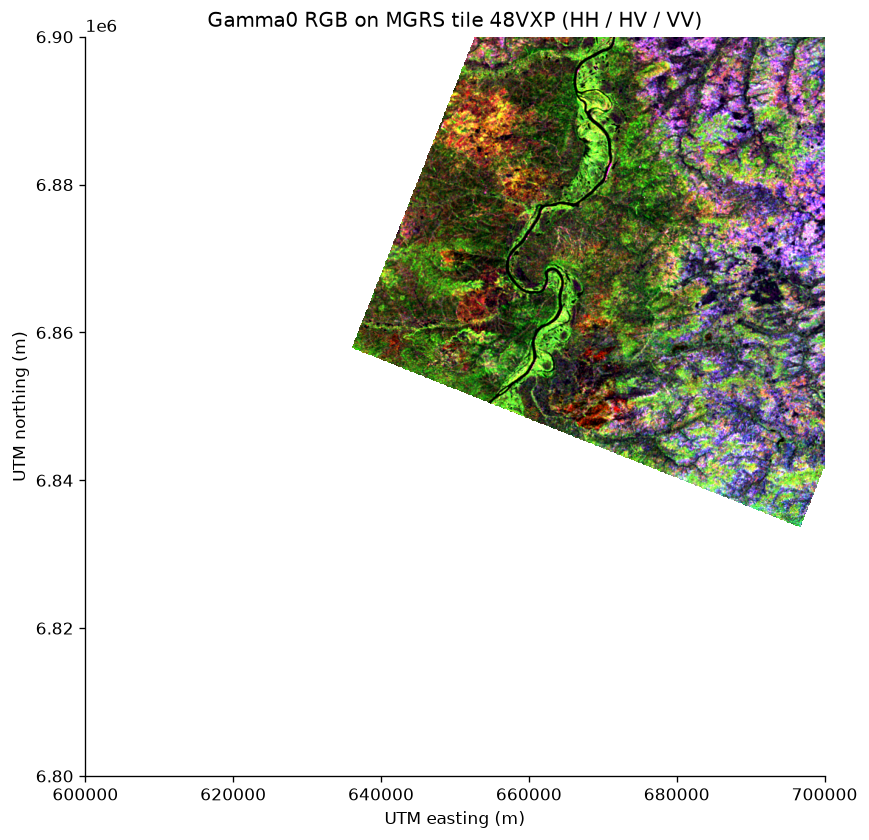

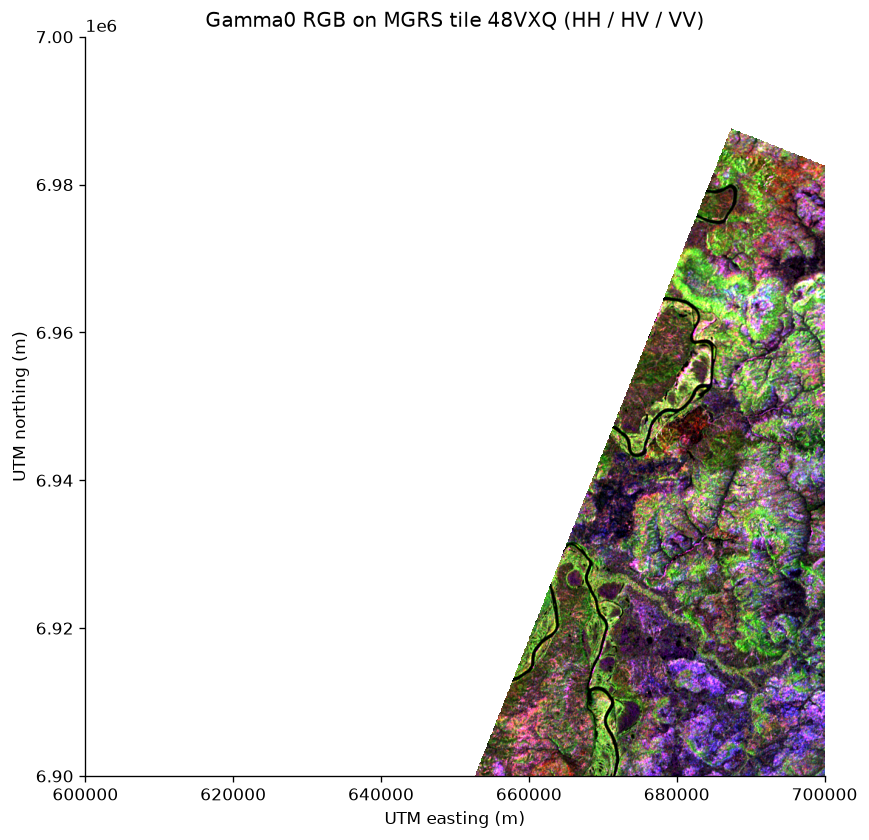

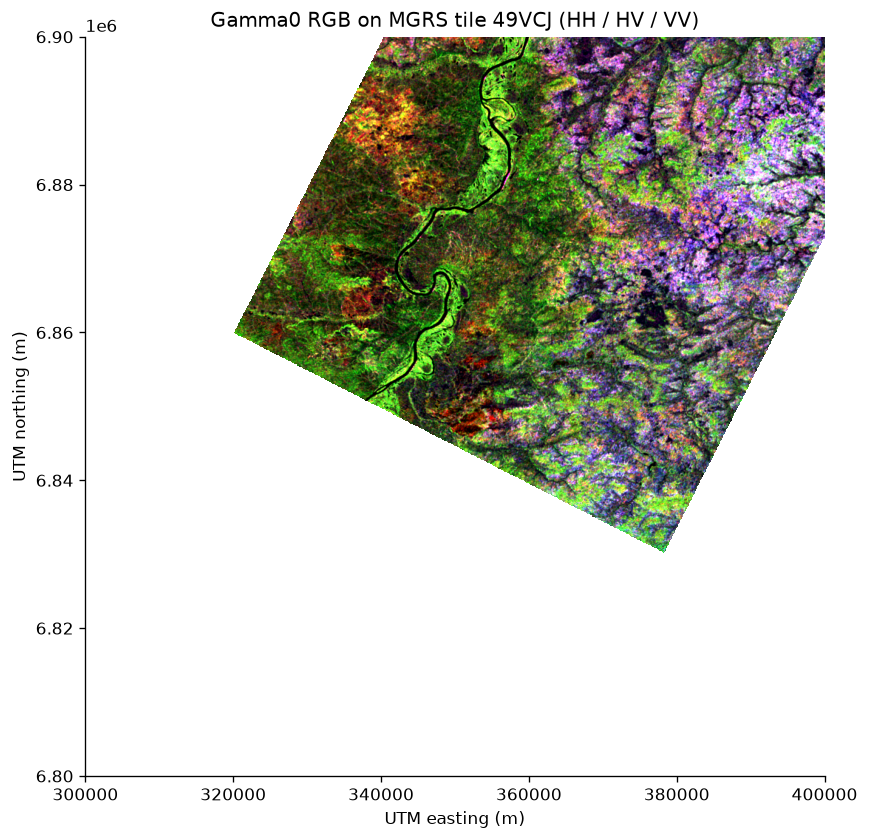

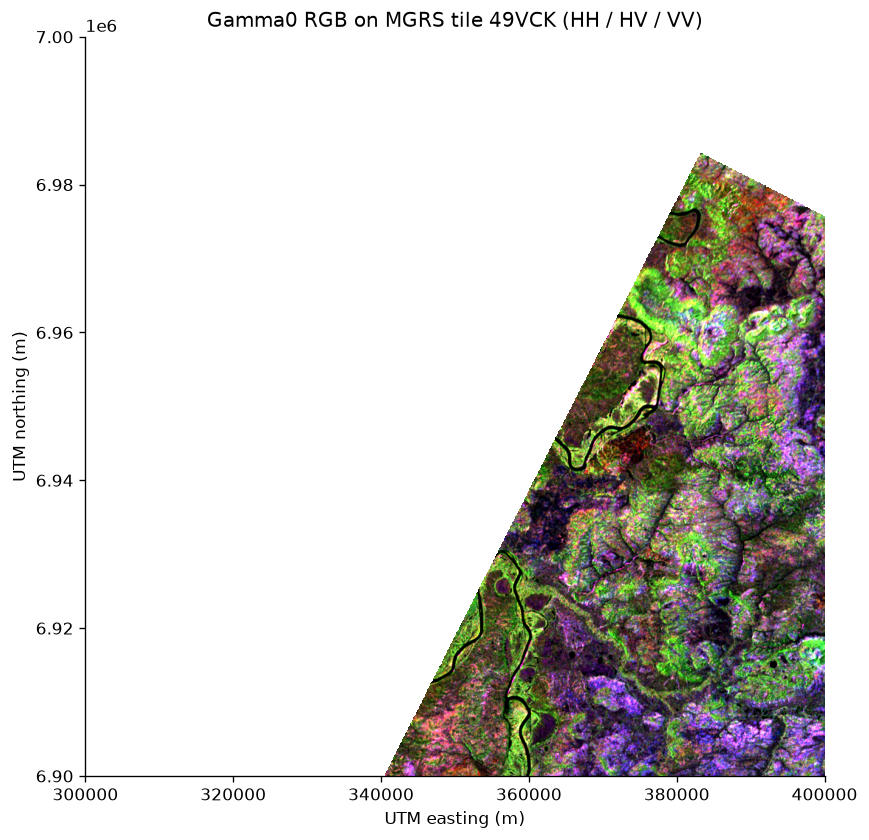

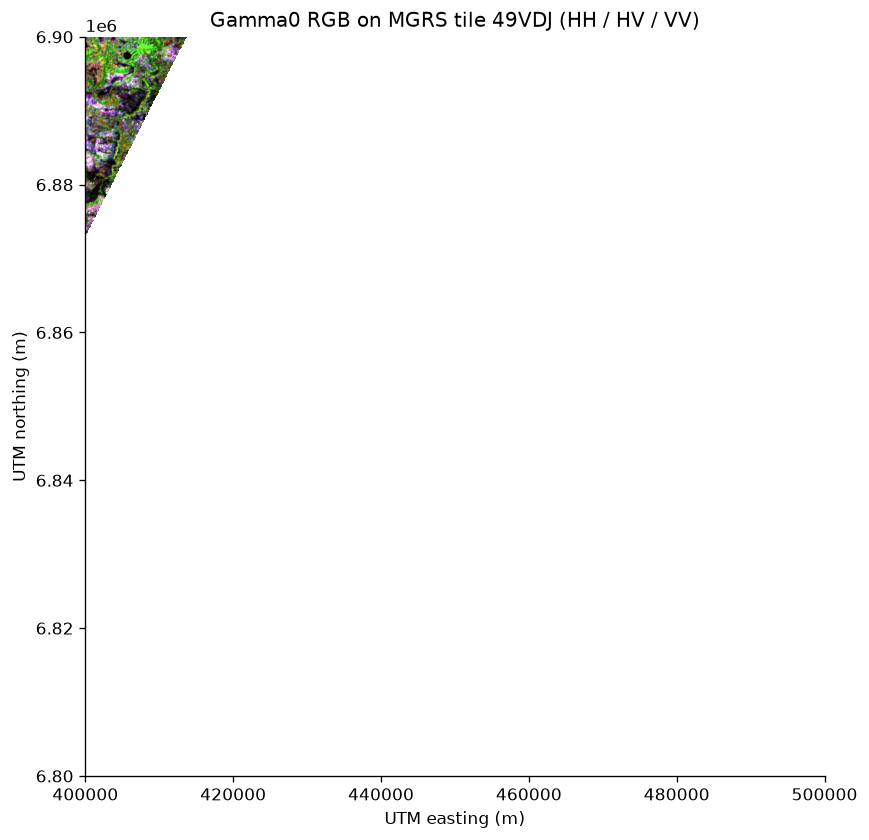

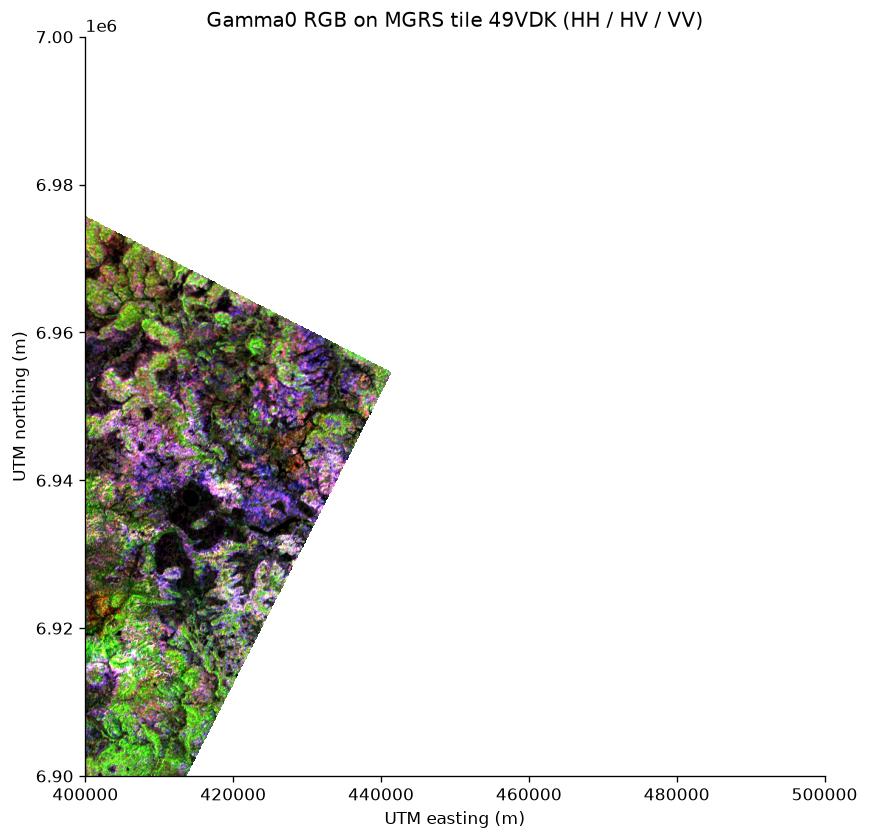

In [13]:
def write_gamma0_cogs(product: dict) -> list[Path]:
    """Write and validate one tiled, single-band Gamma0 COG per polarization."""
    tile_grid = product["grid"]
    acquisition_date = item.datetime.date().isoformat()
    output_dir = OUTPUT_ROOT / tile_grid["tile_id"] / acquisition_date / item.id
    output_dir.mkdir(parents=True, exist_ok=True)
    paths = []
    for index, polarization in enumerate(POLARIZATIONS):
        path = output_dir / f"gamma0_{polarization.lower()}.tif"
        output = np.where(
            np.isfinite(product["gamma0"][index]), product["gamma0"][index], NODATA
        ).astype("float32")
        with rasterio.open(
            path,
            "w",
            driver="COG",
            height=tile_grid["shape"][0],
            width=tile_grid["shape"][1],
            count=1,
            dtype="float32",
            crs=tile_grid["crs"],
            transform=tile_grid["transform"],
            nodata=NODATA,
            blocksize=512,
            compress="DEFLATE",
        ) as dataset:
            dataset.write(output, 1)
            dataset.update_tags(
                QUANTITY="gamma0",
                POLARISATION=polarization,
                UNITS="linear",
                SOURCE_ITEM_ID=item.id,
            )
        with rasterio.open(path) as dataset:
            assert dataset.count == 1
            assert dataset.crs == tile_grid["crs"]
            assert dataset.transform == tile_grid["transform"]
            assert (dataset.height, dataset.width) == tile_grid["shape"]
            assert dataset.nodata == NODATA
        paths.append(path)
    return paths


for product in tile_products:
    tile_grid = product["grid"]
    bounds = rasterio.transform.array_bounds(
        *tile_grid["shape"], tile_grid["transform"]
    )
    extent = (bounds[0], bounds[2], bounds[1], bounds[3])
    rgb = percentile_rgb(product["gamma0"], bands=(0, 1, 3))
    valid = np.isfinite(product["gamma0"]).all(axis=0)

    figure, axis = plt.subplots(figsize=(8, 8))
    axis.imshow(rgb, extent=extent, alpha=valid)
    axis.set(
        title=f"Gamma0 RGB on MGRS tile {tile_grid['tile_id']} (HH / HV / VV)",
        xlabel="UTM easting (m)",
        ylabel="UTM northing (m)",
    )
    axis.set_aspect("equal")
    plt.show()

if WRITE_COGS:
    for product in tile_products:
        for path in write_gamma0_cogs(product):
            print(f"Wrote {path}")

## Takeaways

1. The source Item bbox generates a superset of standard MGRS tiles directly
   through `mgrs`, including candidates across UTM zones.
2. Every candidate gets its exact UTM CRS and 100 km bounds from its MGRS ID;
   GCP back-projection decides whether that tile actually overlaps the radar raster.
3. Gamma0 is calibrated in radar geometry and warped once per polarization to
   each accepted fixed UTM grid.